# Chương 5 – Fundamentals of Machine Learning/Nền tảng học máy

Các nội dung chính:

1. **Generalization / Tổng quát hóa**
2. **Overfitting và underfitting / Học quá khớp và học thiếu**
3. **Noise features / Đặc trưng nhiễu**
4. **Random labels / Nhãn bị xáo trộn**
5. **Learning rate / Tốc độ học**
6. **Model capacity / Năng lực mô hình**
7. **L2 regularization / Điều chuẩn L2**
8. **Dropout / Tắt ngẫu nhiên neuron khi huấn luyện**
9. **Early stopping / Dừng sớm**

## 0. Cài đặt thư viện và cấu hình ban đầu

Cell này import các thư viện cần dùng:

- `numpy`: xử lý dữ liệu dạng mảng số.
- `matplotlib`: vẽ biểu đồ.
- `tensorflow.keras`: xây dựng và huấn luyện neural network.

Một số biến như `MNIST_SAMPLE_SIZE`, `IMDB_EPOCHS` được đặt để notebook chạy nhanh hơn.

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Đặt seed để kết quả có tính lặp lại tương đối.
# Lưu ý: kết quả deep learning vẫn có thể dao động nhẹ tùy môi trường CPU/GPU.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Cấu hình kích thước hình vẽ.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Cấu hình chạy nhanh cho lớp học.
# Nếu máy đủ mạnh, có thể tăng MNIST_SAMPLE_SIZE lên 60000 và IMDB_EPOCHS lên 20.
MNIST_SAMPLE_SIZE = 20000
IMDB_EPOCHS = 20
IMDB_BATCH_SIZE = 512
IMDB_VALIDATION_SPLIT = 0.4

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Hàm tiện ích để vẽ kết quả huấn luyện

Trong Chương 5, ta thường quan sát các đường:

- **training loss / training accuracy**
- **validation loss / validation accuracy**

Những đường này giúp nhận biết model có học được không, có bị overfitting không, và regularization có giúp cải thiện generalization không.

In [5]:
def plot_history_metric(histories, metric, title, ylabel=None):
    """
    Vẽ nhiều đường metric từ các đối tượng History của Keras.

    histories: dict dạng {"Tên đường": history}
    metric: tên metric cần vẽ, ví dụ "val_loss", "val_accuracy"
    title: tiêu đề biểu đồ
    ylabel: nhãn trục y
    """
    plt.figure()
    for name, history in histories.items():
        values = history.history[metric]
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, marker="o", label=name)

    plt.title(title)
    plt.xlabel("Epochs / Số vòng huấn luyện")
    plt.ylabel(ylabel if ylabel is not None else metric)
    plt.legend()
    plt.show()


def plot_train_val(history, title_prefix="Model"):
    """
    Vẽ training loss/validation loss và training accuracy/validation accuracy.
    Dùng để quan sát overfitting hoặc underfitting.
    """
    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history.history["loss"], "o-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "o-", label="Validation loss")
    plt.title(f"{title_prefix}: Training loss vs Validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "accuracy" in history.history:
        plt.figure()
        plt.plot(epochs, history.history["accuracy"], "o-", label="Training accuracy")
        plt.plot(epochs, history.history["val_accuracy"], "o-", label="Validation accuracy")
        plt.title(f"{title_prefix}: Training accuracy vs Validation accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

# 5.1 Generalization / Tổng quát hóa

## 5.1.1 Noise features and spurious correlations / Đặc trưng nhiễu và tương quan giả

Ý tưởng minh họa:

- Model có thể học cả những tín hiệu **không thật sự hữu ích**.
- Nếu thêm các đặc trưng nhiễu vào dữ liệu, thông tin thật không tăng lên.
- Tuy nhiên, model vẫn có thể học các tương quan tình cờ trong phần nhiễu.
- Điều này làm khả năng **generalization / tổng quát hóa** giảm.

Thí nghiệm:

- Dataset gốc: MNIST có 784 pixel cho mỗi ảnh.
- Dataset A: thêm 784 chiều **white noise / nhiễu ngẫu nhiên**.
- Dataset B: thêm 784 chiều **toàn số 0**.
- So sánh validation accuracy của hai model.

Shape dữ liệu gốc: (20000, 784)
Shape dữ liệu có noise channels: (20000, 1568)
Shape dữ liệu có zeros channels: (20000, 1568)
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6994 - loss: 1.0195 - val_accuracy: 0.7990 - val_loss: 0.5705
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8614 - loss: 0.4412 - val_accuracy: 0.8313 - val_loss: 0.4742
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8986 - loss: 0.3284 - val_accuracy: 0.8610 - val_loss: 0.4111
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9249 - loss: 0.2497 - val_accuracy: 0.8788 - val_loss: 0.3572
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9427 - loss: 0.1925 - val_accuracy: 0.9160 - val_loss: 0.2720
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9532 - loss: 0.1540 - val_accuracy: 0.9337 - val_loss: 0.2111
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9665 - loss: 0.1188 - val_accurac

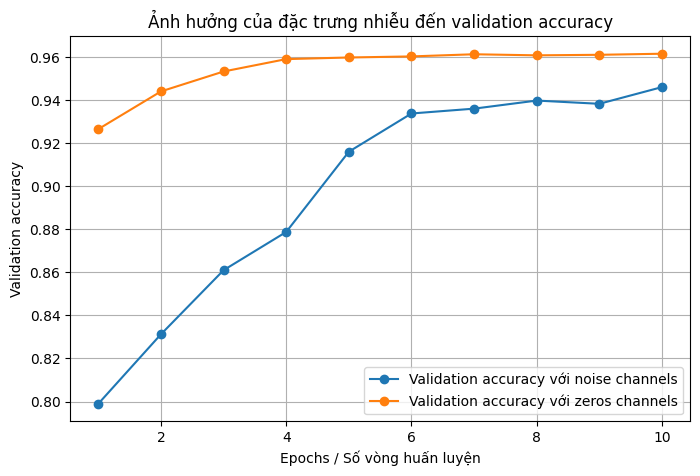

In [6]:
from tensorflow.keras.datasets import mnist

# Tải dữ liệu MNIST.
(train_images, train_labels), _ = mnist.load_data()

# Chuyển ảnh 28x28 thành vector 784 chiều và chuẩn hóa về khoảng [0, 1].
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255.0

# Dùng một phần dữ liệu để demo nhanh trên lớp.
train_images_demo = train_images[:MNIST_SAMPLE_SIZE]
train_labels_demo = train_labels[:MNIST_SAMPLE_SIZE]

# Dataset A: thêm 784 chiều nhiễu ngẫu nhiên.
# Các chiều này không chứa thông tin thật về nhãn chữ số.
# axis=1 nghĩa là nối dữ liệu theo chiều cột / chiều feature.
# NumPy sẽ nối thêm 784 cột noise vào bên phải 784 cột pixel gốc
# 784 pixel gốc + 784 đặc trưng nhiễu = 1568 đặc trưng
train_images_with_noise_channels = np.concatenate(
    [
        train_images_demo,
        np.random.random((len(train_images_demo), 784)).astype("float32")
    ],
    axis=1 
)

# Dataset B: thêm 784 chiều toàn số 0.
# Các chiều này cũng không thêm thông tin, nhưng ít gây nhiễu hơn white noise.
train_images_with_zeros_channels = np.concatenate(
    [
        train_images_demo,
        np.zeros((len(train_images_demo), 784), dtype="float32")
    ],
    axis=1
)

print("Shape dữ liệu gốc:", train_images_demo.shape)
print("Shape dữ liệu có noise channels:", train_images_with_noise_channels.shape)
print("Shape dữ liệu có zeros channels:", train_images_with_zeros_channels.shape)


def get_mnist_dense_model(input_dim):
    """
    Tạo model Dense đơn giản cho MNIST.

    input_dim:
        Số chiều đầu vào.
        Với dữ liệu gốc là 784.
        Với dữ liệu thêm noise/zero channels là 1568.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="rmsprop",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Huấn luyện model trên dữ liệu có noise channels.
model_noise = get_mnist_dense_model(input_dim=train_images_with_noise_channels.shape[1])
history_noise = model_noise.fit(
    train_images_with_noise_channels,
    train_labels_demo,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Huấn luyện model trên dữ liệu có zeros channels.
model_zeros = get_mnist_dense_model(input_dim=train_images_with_zeros_channels.shape[1])
history_zeros = model_zeros.fit(
    train_images_with_zeros_channels,
    train_labels_demo,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# So sánh validation accuracy của hai trường hợp.
plot_history_metric(
    {
        "Validation accuracy với noise channels": history_noise,
        "Validation accuracy với zeros channels": history_zeros,
    },
    metric="val_accuracy",
    title="Ảnh hưởng của đặc trưng nhiễu đến validation accuracy",
    ylabel="Validation accuracy"
)

### Nhận xét

Nếu dữ liệu có **noise channels**, model có nhiều cơ hội học nhầm các tương quan tình cờ. Vì vậy, dù thông tin thật về chữ số không thay đổi, validation accuracy có thể thấp hơn.

Bài học:

- Không phải feature nào thêm vào cũng tốt.
- Feature nhiễu có thể làm model dễ overfit.
- Cần **feature selection / chọn lọc đặc trưng** hoặc **dataset curation / quản lý chất lượng dữ liệu**.

## 5.1.2 Random labels / Nhãn bị xáo trộn

Ý tưởng minh họa:

Deep learning model có thể fit gần như bất kỳ ánh xạ nào nếu đủ capacity, kể cả ánh xạ vô nghĩa.

Thí nghiệm:

- Dùng ảnh MNIST thật.
- Xáo trộn label ngẫu nhiên.
- Model vẫn có thể giảm training loss vì nó đang học thuộc dữ liệu.
- Nhưng validation accuracy không cải thiện thật sự, vì không có quan hệ đúng giữa input và target.

Đây là ví dụ để phân biệt:

- **Optimization / tối ưu hóa trên training set**
- **Generalization / tổng quát hóa trên dữ liệu mới**

In [ ]:
# Tạo bản sao label rồi xáo trộn ngẫu nhiên.
random_train_labels = train_labels_demo.copy()
np.random.shuffle(random_train_labels)

# Dùng dữ liệu MNIST gốc, nhưng label đã bị xáo trộn.
model_random_labels = get_mnist_dense_model(input_dim=784)

history_random_labels = model_random_labels.fit(
    train_images_demo,
    random_train_labels,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_train_val(history_random_labels, title_prefix="MNIST với nhãn bị xáo trộn")

### Nhận xét

Nếu training accuracy tăng nhưng validation accuracy không tăng tương ứng, model có thể đang **ghi nhớ training data** thay vì học quy luật tổng quát.

Với nhãn bị xáo trộn:

- Bài toán không có quy luật thật.
- Không thể generalize tốt.
- Model có thể fit training set nhưng không thể dự đoán tốt trên validation set.

# 5.3 Improving Model Fit / Cải thiện khả năng fit của mô hình

Chương 5 nhấn mạnh ba hướng cải thiện khi model chưa fit tốt:

1. **Tuning gradient descent parameters / Tinh chỉnh tham số gradient descent**
2. **Better architecture priors / Chọn kiến trúc phù hợp hơn**
3. **Increasing model capacity / Tăng năng lực mô hình**

## 5.3.1 Tuning gradient descent parameters / Tinh chỉnh tham số gradient descent

Learning rate quá lớn có thể làm model cập nhật weights quá mạnh, dẫn đến training không ổn định hoặc không vượt qua được mức accuracy thấp.

Thí nghiệm:

- Train MNIST với learning rate rất cao: `1.0`
- Train lại với learning rate hợp lý hơn: `1e-2`
- So sánh validation accuracy.

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5150 - loss: 2038.7987 - val_accuracy: 0.4610 - val_loss: 35.5046
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3517 - loss: 14.5016 - val_accuracy: 0.3088 - val_loss: 2.3985
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2808 - loss: 6.1070 - val_accuracy: 0.2885 - val_loss: 2.4613
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2666 - loss: 2.3977 - val_accuracy: 0.2002 - val_loss: 2.1904
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2237 - loss: 2.5555 - val_accuracy: 0.1992 - val_loss: 2.2094
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2192 - loss: 2.2744 - val_accuracy: 0.2453 - val_loss: 2.4385
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2190 - loss: 2.3396 - val_accuracy: 0.2215 - val_loss: 2.1902
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2579 - loss: 2.3768 - val_accurac

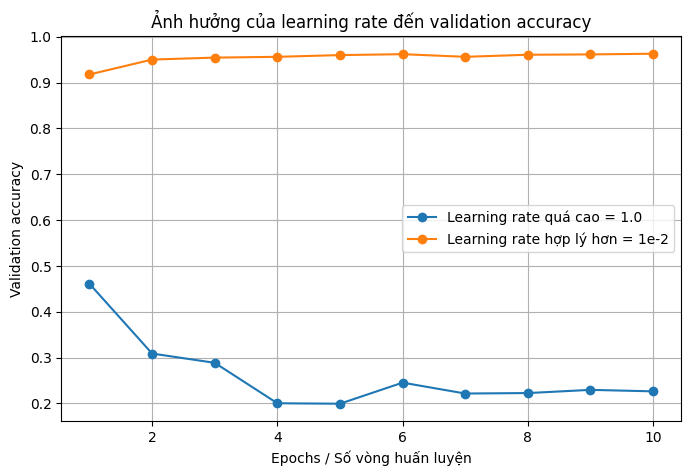

In [7]:
def train_mnist_with_learning_rate(learning_rate, epochs=10):
    """
    Huấn luyện cùng một kiến trúc MNIST với learning rate khác nhau.
    """
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_images_demo,
        train_labels_demo,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )
    return history


history_lr_high = train_mnist_with_learning_rate(learning_rate=1.0, epochs=10)
history_lr_ok = train_mnist_with_learning_rate(learning_rate=1e-2, epochs=10)

plot_history_metric(
    {
        "Learning rate quá cao = 1.0": history_lr_high,
        "Learning rate hợp lý hơn = 1e-2": history_lr_ok,
    },
    metric="val_accuracy",
    title="Ảnh hưởng của learning rate đến validation accuracy",
    ylabel="Validation accuracy"
)

### Nhận xét

Nếu learning rate quá cao:

- Bước cập nhật weights quá lớn.
- Model có thể “nhảy qua” vùng nghiệm tốt.
- Training có thể bị kẹt ở hiệu năng thấp.

Khi learning rate hợp lý hơn:

- Model học ổn định hơn.
- Validation accuracy thường tăng tốt hơn.

## 5.3.3 Increasing model capacity / Tăng năng lực mô hình

Nếu model quá nhỏ, nó có thể **underfit / học thiếu (dưới khớp)**:

- Training loss không đủ thấp.
- Validation loss giảm chậm hoặc sớm plateau (chững lại).
- Model không đủ năng lực để học pattern phức tạp.

Thí nghiệm:

- Dùng logistic regression đơn giản trên MNIST.
- Model chỉ có một lớp Dense softmax.
- Quan sát validation loss.

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7558 - loss: 1.0355 - val_accuracy: 0.8610 - val_loss: 0.6161
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8742 - loss: 0.5028 - val_accuracy: 0.8895 - val_loss: 0.4388
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8935 - loss: 0.4020 - val_accuracy: 0.9015 - val_loss: 0.3801
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9027 - loss: 0.3601 - val_accuracy: 0.9070 - val_loss: 0.3509
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9084 - loss: 0.3361 - val_accuracy: 0.9110 - val_loss: 0.3333
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9122 - loss: 0.3201 - val_accuracy: 0.9125 - val_loss: 0.3214
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9148 - loss: 0.3082 - val_accuracy: 0.9147 - val_loss: 0.3129
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9176 - loss: 0.2990 - val_accuracy: 0.

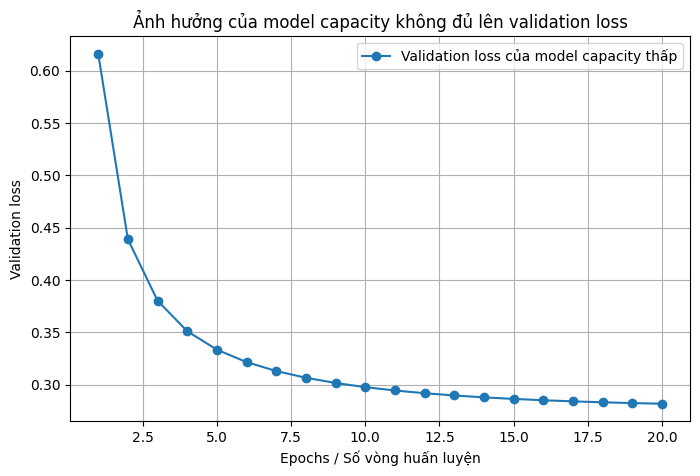

In [8]:
# Model rất đơn giản: chỉ có một lớp Dense.
# Đây gần giống logistic regression đa lớp cho MNIST.
small_mnist_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(10, activation="softmax")
])

small_mnist_model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_small_mnist_model = small_mnist_model.fit(
    train_images_demo,
    train_labels_demo,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_history_metric(
    {"Validation loss của model capacity thấp": history_small_mnist_model},
    metric="val_loss",
    title="Ảnh hưởng của model capacity không đủ lên validation loss",
    ylabel="Validation loss"
)

### Nhận xét

Nếu validation loss giảm rồi nhanh chóng đi ngang ở mức chưa tốt, model có thể đang thiếu capacity.

Cách xử lý:

- Tăng số layer.
- Tăng số units.
- Chọn architecture phù hợp hơn với dữ liệu.
- Cải thiện feature engineering.

# 5.4 Improving Generalization / Cải thiện khả năng tổng quát hóa

Sau khi model đã fit được training data, câu hỏi tiếp theo là:

> Làm sao để model hoạt động tốt trên dữ liệu mới?

Chương 5 minh họa nhiều cách:

- giảm kích thước mạng,
- thêm weight regularization,
- dùng dropout,
- dùng early stopping.

## Chuẩn bị dữ liệu IMDB

Các thí nghiệm regularization trong Chương 5 dùng bài toán **IMDB review classification**:

- Input: review phim.
- Target: positive hoặc negative.
- Dạng bài toán: binary classification.
- Biểu diễn dữ liệu: multi-hot vector với 10.000 từ phổ biến nhất.

In [9]:
from tensorflow.keras.datasets import imdb

# Chỉ giữ 10.000 từ phổ biến nhất.
(train_data, train_labels), _ = imdb.load_data(num_words=10000)


def vectorize_sequences(sequences, dimension=10000):
    """
    Chuyển mỗi review từ danh sách word indices sang vector multi-hot.

    Ví dụ:
    sequence = [3, 10, 15]
    => vector có vị trí 3, 10, 15 bằng 1; các vị trí khác bằng 0.
    """
    results = np.zeros((len(sequences), dimension), dtype="float32")
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results


train_data = vectorize_sequences(train_data)
train_labels = train_labels.astype("float32")

print("Shape train_data:", train_data.shape)
print("Shape train_labels:", train_labels.shape)

Shape train_data: (25000, 10000)
Shape train_labels: (25000,)


## 5.4.4 Reducing the network's size / Giảm kích thước mạng

Ý tưởng:

- Model quá lớn có nhiều tham số, dễ ghi nhớ training data.
- Giảm số units/layers là một cách regularization đơn giản.
- Model nhỏ hơn thường overfit chậm hơn, nhưng nếu quá nhỏ sẽ underfit.

Ta sẽ train 3 model:

1. **Original model**: 16 units + 16 units
2. **Smaller model**: 4 units + 4 units
3. **Larger model**: 512 units + 512 units

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7779 - loss: 0.5267 - val_accuracy: 0.8620 - val_loss: 0.4001
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8966 - loss: 0.3174 - val_accuracy: 0.8875 - val_loss: 0.3064
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9223 - loss: 0.2369 - val_accuracy: 0.8805 - val_loss: 0.2992
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9377 - loss: 0.1895 - val_accuracy: 0.8856 - val_loss: 0.2882
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9474 - loss: 0.1609 - val_accuracy: 0.8889 - val_loss: 0.2829
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9593 - loss: 0.1320 - val_accuracy: 0.8875 - val_loss: 0.2945
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9645 - loss: 0.1164 - val_accuracy: 0.8824 - val_loss: 0.3141
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9695 - loss: 0.1009 - val_accuracy: 0.8824 - v

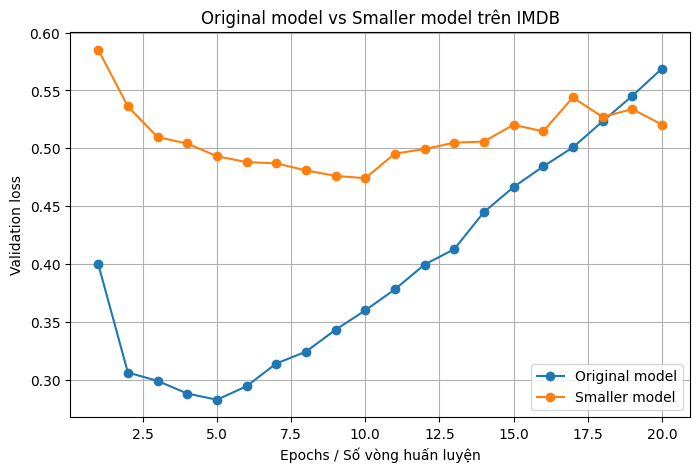

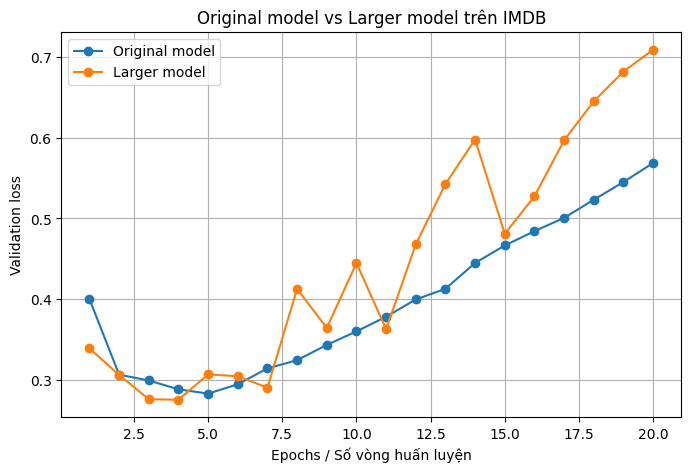

In [10]:
def build_imdb_model(units=16, regularizer=None, dropout_rate=None):
    """
    Tạo model phân loại review IMDB.

    units:
        Số neuron trong mỗi hidden layer.
    regularizer:
        Regularizer áp dụng cho kernel weights, ví dụ regularizers.l2(0.002).
    dropout_rate:
        Nếu khác None, thêm Dropout sau mỗi hidden layer.
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(10000,)))
    model.add(layers.Dense(units, activation="relu", kernel_regularizer=regularizer))

    if dropout_rate is not None:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(units, activation="relu", kernel_regularizer=regularizer))

    if dropout_rate is not None:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Model gốc: chưa dùng L1/L2/dropout.
model_original = build_imdb_model(units=16)
history_original = model_original.fit(
    train_data,
    train_labels,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_split=IMDB_VALIDATION_SPLIT,
    verbose=1
)

# Model nhỏ hơn: ít units hơn, ít khả năng ghi nhớ hơn.
model_smaller = build_imdb_model(units=4)
history_smaller_model = model_smaller.fit(
    train_data,
    train_labels,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_split=IMDB_VALIDATION_SPLIT,
    verbose=1
)

# Model lớn hơn: nhiều units hơn, dễ overfit hơn.
model_larger = build_imdb_model(units=512)
history_larger_model = model_larger.fit(
    train_data,
    train_labels,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_split=IMDB_VALIDATION_SPLIT,
    verbose=1
)

plot_history_metric(
    {
        "Original model": history_original,
        "Smaller model": history_smaller_model,
    },
    metric="val_loss",
    title="Original model vs Smaller model trên IMDB",
    ylabel="Validation loss"
)

plot_history_metric(
    {
        "Original model": history_original,
        "Larger model": history_larger_model,
    },
    metric="val_loss",
    title="Original model vs Larger model trên IMDB",
    ylabel="Validation loss"
)

### Nhận xét

- **Smaller model** thường overfit muộn hơn vì có ít tham số hơn.
- **Larger model** thường overfit rất nhanh vì có quá nhiều memorization capacity.
- Mục tiêu không phải chọn model nhỏ nhất hay lớn nhất, mà là chọn model có capacity vừa đủ.

## Adding weight regularization / Thêm điều chuẩn trọng số

Ý tưởng:

L2 regularization thêm một khoản phạt vào loss nếu weights quá lớn.

Công thức trực giác:

`Loss mới = Loss gốc + λ × tổng(w²)`

Tác dụng:

- ép weights nhỏ hơn,
- làm model mượt hơn,
- giảm khả năng học thuộc training data,
- cải thiện generalization.

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7745 - loss: 0.6188 - val_accuracy: 0.8641 - val_loss: 0.4871
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8893 - loss: 0.4170 - val_accuracy: 0.8809 - val_loss: 0.4002
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9115 - loss: 0.3411 - val_accuracy: 0.8846 - val_loss: 0.3717
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9237 - loss: 0.3045 - val_accuracy: 0.8826 - val_loss: 0.3640
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9322 - loss: 0.2798 - val_accuracy: 0.8830 - val_loss: 0.3640
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9365 - loss: 0.2670 - val_accuracy: 0.8838 - val_loss: 0.3624
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9407 - loss: 0.2535 - val_accuracy: 0.8829 - val_loss: 0.3675
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9437 - loss: 0.2467 - val_accuracy: 0.8836 - v

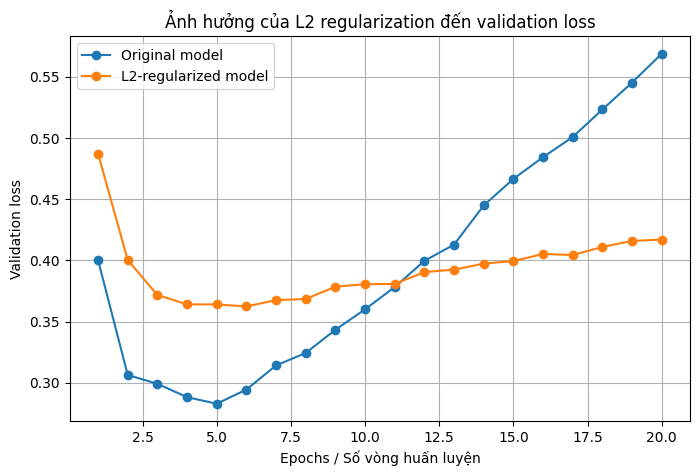

L1 regularizer: <keras.src.regularizers.regularizers.L1 object at 0x000001D73F316720>
L1 + L2 regularizer: <keras.src.regularizers.regularizers.L1L2 object at 0x000001D728D9F8C0>


In [11]:
# Model có L2 regularization.
# l2(0.002) nghĩa là mỗi weight coefficient bị phạt theo 0.002 * weight^2.
model_l2 = build_imdb_model(
    units=16,
    regularizer=regularizers.l2(0.002)
)

history_l2_reg = model_l2.fit(
    train_data,
    train_labels,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_split=IMDB_VALIDATION_SPLIT,
    verbose=1
)

plot_history_metric(
    {
        "Original model": history_original,
        "L2-regularized model": history_l2_reg,
    },
    metric="val_loss",
    title="Ảnh hưởng của L2 regularization đến validation loss",
    ylabel="Validation loss"
)

# Một số regularizer khác trong Keras.
# Cell này chỉ minh họa cú pháp, không train model.
l1_regularizer = regularizers.l1(0.001)
l1_l2_regularizer = regularizers.l1_l2(l1=0.001, l2=0.001)

print("L1 regularizer:", l1_regularizer)
print("L1 + L2 regularizer:", l1_l2_regularizer)

### Nhận xét

- Model gốc không dùng L1/L2.
- Model L2 có cùng số units như model gốc nhưng bị ràng buộc weights.
- Nếu đường validation loss của model L2 tăng chậm hơn, L2 đang giúp giảm overfitting.

## Adding Dropout / Thêm Dropout

Dropout là kỹ thuật regularization rất phổ biến trong neural network.

Ý tưởng:

- Trong training, ngẫu nhiên đặt một phần activation về 0.
- Model không thể phụ thuộc quá nhiều vào một vài neuron.
- Khi inference/test, không tắt neuron nữa.

Ví dụ:

- Dropout rate = 0.5 nghĩa là tắt ngẫu nhiên 50% activation trong training.

Activation ban đầu:
[[0.3 0.2 1.5 0. ]
 [0.6 0.1 0.  0.3]
 [0.2 1.9 0.3 1.2]
 [0.7 0.5 1.  0. ]]

Dropout mask:
[[0. 1. 1. 0.]
 [1. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 1.]]

Activation sau khi áp dụng dropout và rescale:
[[0.  0.4 3.  0. ]
 [1.2 0.2 0.  0. ]
 [0.4 0.  0.  0. ]
 [0.  0.  2.  0. ]]
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6010 - loss: 0.6543 - val_accuracy: 0.8207 - val_loss: 0.5500
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7264 - loss: 0.5526 - val_accuracy: 0.8661 - val_loss: 0.4370
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7955 - loss: 0.4600 - val_accuracy: 0.8821 - val_loss: 0.3513
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8357 - loss: 0.3960 - val_accuracy: 0.8857 - val_loss: 0.3068
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8665 - loss: 0.3405 - val_accuracy: 0.8889 - val_loss: 0.2829
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.89

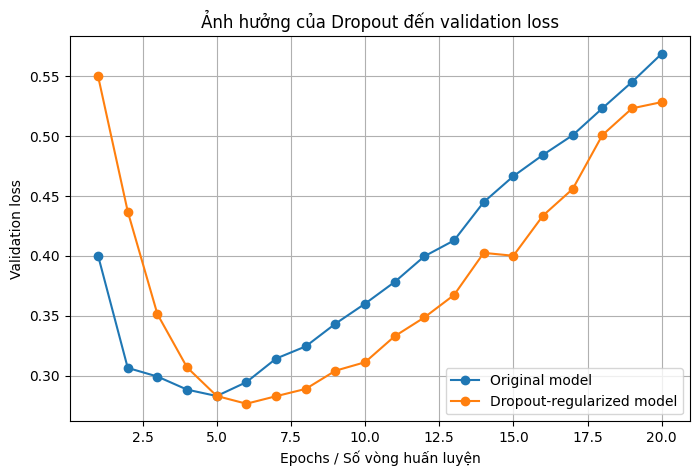

In [12]:
# Minh họa dropout bằng NumPy trên một ma trận activation nhỏ.
layer_output = np.array([
    [0.3, 0.2, 1.5, 0.0],
    [0.6, 0.1, 0.0, 0.3],
    [0.2, 1.9, 0.3, 1.2],
    [0.7, 0.5, 1.0, 0.0],
], dtype="float32")

dropout_rate = 0.5
keep_rate = 1.0 - dropout_rate

# Tạo mask ngẫu nhiên: 1 là giữ lại, 0 là tắt.
dropout_mask = np.random.randint(0, high=2, size=layer_output.shape).astype("float32")

# Áp dụng dropout và rescale trong training.
# Chia cho keep_rate để giữ độ lớn trung bình của tín hiệu.
layer_output_after_dropout = layer_output * dropout_mask / keep_rate

print("Activation ban đầu:")
print(layer_output)

print("\nDropout mask:")
print(dropout_mask)

print("\nActivation sau khi áp dụng dropout và rescale:")
print(layer_output_after_dropout)

# Model có Dropout regularization.
model_dropout = build_imdb_model(
    units=16,
    dropout_rate=0.5
)

history_dropout = model_dropout.fit(
    train_data,
    train_labels,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_split=IMDB_VALIDATION_SPLIT,
    verbose=1
)

plot_history_metric(
    {
        "Original model": history_original,
        "Dropout-regularized model": history_dropout,
    },
    metric="val_loss",
    title="Ảnh hưởng của Dropout đến validation loss",
    ylabel="Validation loss"
)

### Nhận xét

Nếu Dropout hiệu quả, ta thường thấy:

- validation loss tăng chậm hơn,
- overfitting xảy ra muộn hơn,
- khoảng cách giữa training và validation performance giảm.

Dropout không làm model hết overfitting hoàn toàn, nhưng thường giúp model tổng quát hóa tốt hơn.

## Early stopping / Dừng sớm

Ý tưởng:

Khi validation loss không còn cải thiện, ta dừng training để tránh overfitting.

Trong Keras:

- `EarlyStopping` dừng training khi metric không cải thiện sau một số epoch.
- `restore_best_weights=True` giúp khôi phục weights ở epoch tốt nhất.

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7782 - loss: 0.5164 - val_accuracy: 0.8667 - val_loss: 0.3847
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8951 - loss: 0.3120 - val_accuracy: 0.8832 - val_loss: 0.3077
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9211 - loss: 0.2371 - val_accuracy: 0.8874 - val_loss: 0.2873
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9373 - loss: 0.1911 - val_accuracy: 0.8912 - val_loss: 0.2754
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9454 - loss: 0.1630 - val_accuracy: 0.8849 - val_loss: 0.2872
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9571 - loss: 0.1357 - val_accuracy: 0.8845 - val_loss: 0.2972
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9621 - loss: 0.1199 - val_accuracy: 0.8838 - val_loss: 0.3073


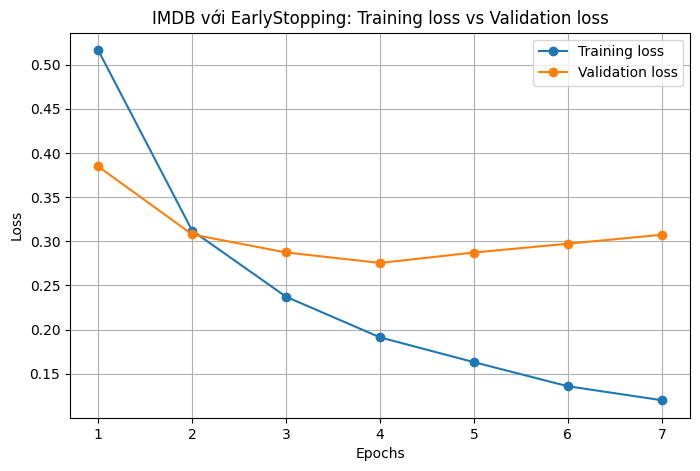

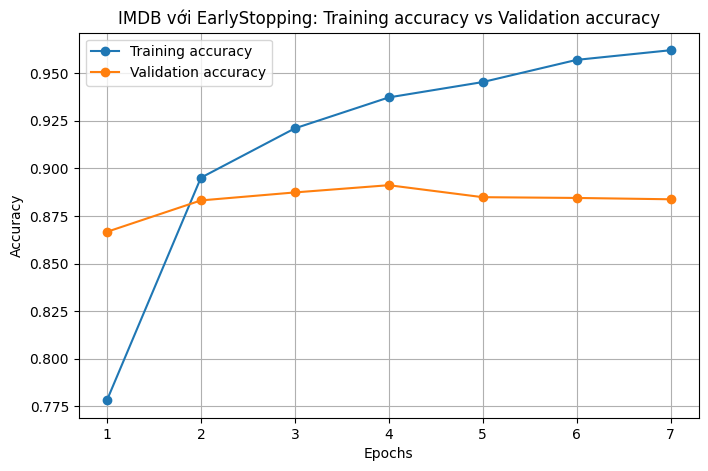

In [13]:
# Ví dụ EarlyStopping trên IMDB.
# Có thể chạy cell này để xem model tự dừng sớm khi val_loss không cải thiện.

model_early_stopping = build_imdb_model(units=16)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",           # Theo dõi validation loss
    patience=3,                   # Chờ 3 epoch không cải thiện rồi dừng
    restore_best_weights=True     # Khôi phục weights tốt nhất
)

history_early_stopping = model_early_stopping.fit(
    train_data,
    train_labels,
    epochs=50,                    # Đặt lớn, callback sẽ tự dừng sớm nếu cần
    batch_size=IMDB_BATCH_SIZE,
    validation_split=IMDB_VALIDATION_SPLIT,
    callbacks=[early_stopping],
    verbose=1
)

plot_train_val(history_early_stopping, title_prefix="IMDB với EarlyStopping")

# Tổng kết bài học từ notebook

## 1. Generalization / Tổng quát hóa

Model không chỉ cần học tốt training set, mà phải hoạt động tốt trên dữ liệu mới.

## 2. Noise features / Đặc trưng nhiễu

Thêm feature không hữu ích có thể làm model học nhầm tương quan giả.

## 3. Random labels / Nhãn ngẫu nhiên

Model có thể fit dữ liệu vô nghĩa, nhưng không thể generalize nếu input-target không có quan hệ thật.

## 4. Learning rate

Learning rate quá cao có thể làm training kém ổn định.

## 5. Model capacity

- Quá nhỏ → underfitting.
- Quá lớn → overfitting.
- Cần tìm capacity vừa đủ.

## 6. Regularization

Các kỹ thuật như giảm kích thước model, L2 regularization, Dropout và EarlyStopping giúp giảm overfitting.